In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import pandas as pd

import sys
import h5py
sys.path.append('T:\EL_experiment\Codes\CCEP_human\Python_Analysis/py_functions')

from scipy.stats import norm
from tkinter import *
import scipy
from scipy import signal

import platform
from glob import glob
from scipy.spatial import distance
import basic_func as bf
from scipy.integrate import simps
from numpy import trapz
import IO_func as IOF
import tqdm
from matplotlib.patches import Rectangle
from pathlib import Path
import LL_funcs as LLf
import freq_funcs as ff
#
from scipy.signal import hilbert, butter, filtfilt
import scipy.stats as stats
from tqdm.notebook import trange, tqdm
import significance_funcs as sig_func

dist_groups = np.array([[0, 30], [30, 60], [60, 120]])
dist_labels = ['local (<30 mm)', 'short (<60mm)', 'long']
Fs = 500
dur = np.zeros((1, 2), dtype=np.int32)
t0 = 1
dur[0, 0] = -t0
dur[0, 1] = 3

folder = 'PairedPulse'
# dur[0,:]       = np.int32(np.sum(abs(dur)))
x_ax = np.arange(dur[0, 0], dur[0, 1], (1 / Fs))
color_elab = np.zeros((3, 3))
color_elab[0, :] = np.array([31, 78, 121]) / 255
color_elab[1, :] = np.array([189, 215, 238]) / 255
color_elab[2, :] = np.array([0.256, 0.574, 0.431])
cwd = os.getcwd()

In [2]:
sub_path = 'X:\\4 e-Lab\\'  # y:\\eLab

In [3]:
plt.rcParams.update({
            'font.family': 'arial',
            'font.size': 12,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 9,
            'svg.fonttype': 'none',
            'font.size': 10,
            'axes.titlesize': 10,
            'axes.labelsize': 8,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 9,
            'figure.titlesize': 10
        })

In [4]:
subj = 'EL003'
cond_folder = 'CR'  # Condition = 'Hour', 'Condition', 'Ph'

if cond_folder == 'Ph':
    cond_vals = np.arange(4)
    cond_labels = ['BM', 'BL', 'Fuma', 'BZD']
    cond_colors = ['#494159', '#594157', "#F1BF98", "#8FB996"]
    cond1 = 'Condition'  # 'condition', 'h'
    cond_folder = 'Ph'  # 'Ph', 'Sleep', 'CR'
    Condition = 'Condition'
if cond_folder == 'CR':
    Condition = 'Hour'  # Condition = 'Hour'
    cond1 = 'h'  # h (as stored in stimlist)

######## General Infos

path_patient_analysis = os.path.join(sub_path, 'EvM', 'Projects', 'EL_experiment', 'Analysis', 'Patients', subj)
path_gen = os.path.join(sub_path+'\Patients\\' + subj)
if not os.path.exists(path_gen):
    path_gen = 'T:\\EL_experiment\\Patients\\' + subj
path_patient = path_gen + '\Data\EL_experiment'  # os.path.dirname(os.path.dirname(cwd))+'/Patients/'+subj
path_infos = os.path.join(path_gen, 'Electrodes')

sep = ';'
Fs = 500

files_list = glob(path_patient_analysis + '\\' + folder + '/data/Stim_list_*')
i = 0
stimlist = pd.read_csv(files_list[-1])
# EEG_resp = np.load(path_patient_analysis + '\\' + folder + '/data/ALL_resps_'+files_list[i][-11:-4]+'.npy')
lbls = pd.read_excel(os.path.join(path_infos, subj + "_labels.xlsx"), header=0, sheet_name='BP')
if 'type'in lbls:
    lbls = lbls[lbls.type == 'SEEG'].reset_index(drop=True)
labels_all, labels_region, labels_clinic, coord_all, StimChans, StimChanSM, StimChansC, StimChanIx, stimlist = bf.get_Stim_chans(
    stimlist,
    lbls)
 
labels_h = lbls.Hemisphere + '_' + labels_all


R_ENT
R_ENT
R_ENT
R_FusG
R_FusG
R_FusG
R_MTG
R_ENT
R_HIPP_Presubiculum
R_HIPP_Mol
R_HIPP_Mol
R_ITG
R_ITG
R_ITG
R_ITS
R_HIPP_Mol
R_WM
R_STS
R_STS
R_STS
R_STS
R_STS
R_STG
R_WM
R_WM
R_WM
R_MTG_post
R_MTG_post
R_MTG_post
R_MTG_post
R_WM
R_WM
R_SMargG
R_SMargG
R_SMargG
R_AngG
R_AngG
R_AngG
R_WM
R_WM
R_WM
R_SMargG
R_SMargG
R_SMargG
R_SMargG
R_ParahipG
R_HIPP_Subiculum
R_HIPP_Subiculum
R_HIPP_CA1
R_OTS_lat
R_STS
R_STS
R_TTG
R_TTG
R_TTG
R_TTG
R_TTG
R_STG_ant
R_STG_ant
R_TTG


In [5]:
file_con = path_patient_analysis + '\\' + folder + '/' + cond_folder + '/data/con_trial_all.csv'
######### Load data
rerun = 0
if os.path.isfile(file_con):
    print('get con_trial')
    con_trial = pd.read_csv(file_con)

get con_trial


In [6]:
Fs             = 500
dur            = np.zeros((1,2), dtype=np.int32)
t0 = 1
dur[0,0] =  -t0
dur[0,1] =  3

#dur[0,:]       = np.int32(np.sum(abs(dur)))
x_ax           = np.arange(dur[0,0],dur[0,1],(1/Fs))
color_elab      = np.zeros((4,3))
color_elab[0,:] = np.array([31, 78, 121])/255
color_elab[1,:] = np.array([189, 215, 238])/255
color_elab[2,:] = np.array([0.256, 0.574, 0.431])


## Plots for first block

In [7]:
h5_file = path_patient_analysis + '\\' + folder + '\\' + cond_folder + '\\data\\EEG_' + cond_folder + '.h5'
if os.path.isfile(h5_file):
    print('loading h5')
    EEG_resp = h5py.File(h5_file)
    EEG_resp = EEG_resp['EEG_resp']

loading h5


In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from scipy.integrate import simps 
import sklearn

In [9]:
plt.rcParams.update({
            'font.family': 'arial',
            'font.size': 12,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 9,
            'svg.fonttype': 'none',
            'font.size': 10,
            'axes.titlesize': 10,
            'axes.labelsize': 8,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 9,
            'figure.titlesize': 10
        })

In [27]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd

def plot_LL_IPI_general(sc, rc, ipis, con_trial, EEG_resp, labels_all, ylim = 600, Fs=500, t0=1):
    colorblind_palette = sns.color_palette("colorblind")
    data_plot = con_trial[(con_trial.Chan==rc) & (con_trial.Stim==sc) & (con_trial.Artefact<1)].reset_index(drop=True)
    
    fig = plt.figure(figsize=(8,8))
    fig.patch.set_facecolor('xkcd:white')
    plt.suptitle(subj+':  '+labels_all[sc]+' - '+labels_all[rc])
    gs = gridspec.GridSpec(4, len(ipis), figure=fig, height_ratios=[1.5, 1,1, 1])
    fig.subplots_adjust(wspace=0.05)
    # Plot sns plot on first row (across all three subplots)
    ax_ipi = plt.subplot(gs[0, :])
    bl_LL = data_plot.loc[(data_plot.IPI == 0), 'LL'].values
    sns.lineplot(x='IPI', y='LL', hue='Intc', data=data_plot[data_plot.IPI>16], palette='colorblind', ax=ax_ipi)
    ax_ipi.set_xscale('log')
    ax_ipi.set_ylabel('LL [uV/ms]')
    ax_ipi.set_xlabel('IPI [ms]')
    ax_ipi.axhline(np.median(bl_LL),color='gray', label = 'SP')
    ax_ipi.legend()
    # ax_ipi.axhspan(np.median(bl_LL)-np.std(bl_LL),np.median(bl_LL)+np.std(bl_LL),color='k', alpha = 0.1)
    # get BL signal
    data_plot_ipi = data_plot[data_plot.Intc == 0].reset_index(drop=True)
    mn_bl = np.mean(EEG_resp[rc, data_plot_ipi.Num.values, :], axis=0)
    
    for ix_ipi, ipi_sel in enumerate(ipis):
        ax_ipi.axvline(ipi_sel, color='k', ls='--', linewidth=1)
        for ix_int, int_sel in enumerate([1, 2, 4]):
            ax = plt.subplot(gs[ix_int+1, ix_ipi])
            data_plot_ipi = data_plot[(data_plot.Intc == int_sel) & (data_plot.IPI == ipi_sel)].reset_index(drop=True)
            mn = np.mean(EEG_resp[rc, data_plot_ipi.Num.values, :], axis=0)
            ax.plot(x_ax - ipi_sel/1000, mn, color = colorblind_palette[ix_int])
            ax.plot(x_ax, mn_bl, color= 'k', label='Baseline', alpha = 0.5)
            ax.set_xlim([-0.01, 0.5])
            # ax.legend()
            ax.set_ylim([-ylim, ylim])
            if ix_ipi ==0:
                ax.set_ylabel(str(int_sel)+'mA')
            else:
                ax.set_yticks([])

            if (ix_int== 2)&(ix_ipi ==0):  
                ax.set_xlabel('Time post probing pulse [s] ')
            else:
                ax.set_xticks([])
            if ix_int == 0:
                ax.set_title('IPI: '+str(ipi_sel)+'ms')


    # plt.tight_layout()
    return fig


## Plot Examples

In [11]:
if subj =='EL003':
    con_trial['Time'] = pd.to_datetime(con_trial['Time'])
    con_trial['Date'] = con_trial['Time'].dt.strftime('%Y%m%d').astype(int)
    #con_trial = con_trial[con_trial.Date <20200819].reset_index(drop=True)

In [18]:
con_trial = con_trial[con_trial.Date <20200818].reset_index(drop=True)

In [17]:
np.unique(con_trial.Date)

array([20200814, 20200815, 20200818, 20200819])

In [12]:
stim_all = np.unique(con_trial.Stim)
stim_all

array([ 1,  9, 35, 56], dtype=int64)

In [13]:
labels_all

array(['R_ENT1', 'R_ENT2', 'R_ENT3', 'R_FusG4', 'R_FusG5', 'R_FusG6',
       'R_MTG7', 'R_ENT8', 'R_HIPP_Presubiculum9', 'R_HIPP_Mol10',
       'R_HIPP_Mol11', 'R_ITG12', 'R_ITG13', 'R_ITG14', 'R_ITS15',
       'R_HIPP_Mol16', 'R_WM17', 'R_STS18', 'R_STS19', 'R_STS20',
       'R_STS21', 'R_STS22', 'R_STG23', 'R_WM24', 'R_WM25', 'R_WM26',
       'R_MTG_post27', 'R_MTG_post28', 'R_MTG_post29', 'R_MTG_post30',
       'R_WM31', 'R_WM32', 'R_SMargG33', 'R_SMargG34', 'R_SMargG35',
       'R_AngG36', 'R_AngG37', 'R_AngG38', 'R_WM39', 'R_WM40', 'R_WM41',
       'R_SMargG42', 'R_SMargG43', 'R_SMargG44', 'R_SMargG45',
       'R_ParahipG46', 'R_HIPP_Subiculum47', 'R_HIPP_Subiculum48',
       'R_HIPP_CA149', 'R_OTS_lat50', 'R_STS51', 'R_STS52', 'R_TTG53',
       'R_TTG54', 'R_TTG55', 'R_TTG56', 'R_TTG57', 'R_STG_ant58',
       'R_STG_ant59', 'R_TTG60'], dtype=object)

In [14]:
labels_all[21]

'R_STS22'

In [15]:
stop

NameError: name 'stop' is not defined

In [21]:
np.unique(con_trial.IPI)

array([   0. ,   10.7,   12.7,   15.1,   18. ,   21.4,   25.5,   30.4,
         36.2,   43.1,   51.3,   61.1,   72.8,   86.7,  103.2,  122.9,
        146.4,  174.3,  207.6,  247.2,  294.4,  350.6,  417.5,  497.2,
        592.1,  705.1,  839.7, 1000. , 1300. , 1600. ])

In [35]:
labels_clinic[48]

'HippM04-HippM05'

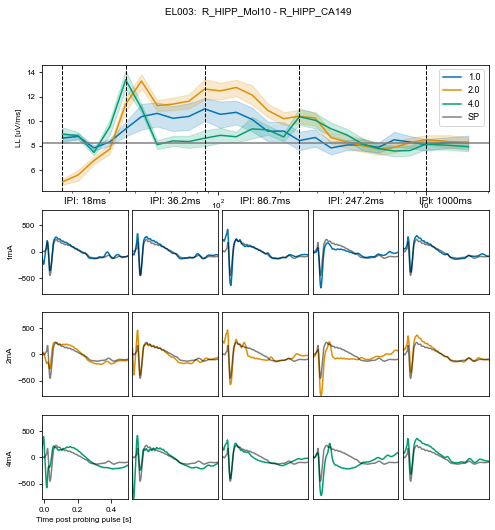

In [42]:
sc = 9
rc = 48
fig = plot_LL_IPI_general(sc, rc, [18,  36.2,86.7,247.2, 1000], con_trial, EEG_resp, labels_all, ylim = 800, Fs=500, t0=1)
filename = 'X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\PP\General\Examples\\'+subj+'_'+labels_all[sc]+'_'+labels_all[rc]+'.svg'
plt.savefig(filename)